# Earthworm classification: colour-cue robustness and matched-condition adaptation

This notebook analyses the outputs produced by the aggregation script for the earthworm multitask classification experiments.

It addresses two complementary questions:

1. **Colour-cue dependence:** How much does an RGB-trained model deteriorate when colour saturation is reduced at test time?
2. **Matched-condition adaptation:** How much performance is recovered when the model is trained, validated, and tested under the same colour condition?

The analysis treats **species macro-F1** as the primary outcome while retaining separate results for **genus**, **species**, and **age/life stage**. It compares ConvNeXt and ViT models, reports performance relative to the original RGB condition, and quantifies the gain obtained by matched-condition training.

> The available aggregated files compare RGB-trained stress tests with matched-condition runs. They do not necessarily constitute a complete train-condition × test-condition domain-generalisation matrix.


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

# Use the same directory supplied as `results_root` to the aggregation script.
PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "config.yaml").is_file()), Path.cwd())
RESULTS_ROOT = PROJECT_ROOT / "outputs_slurm/persistent_cache_sweep_20260713_150423"

FIGURE_DIR = RESULTS_ROOT / "figures_colour_robustness"
TABLE_DIR = RESULTS_ROOT / "tables_colour_robustness"

SAVE_FIGURES = True
SAVE_TABLES = True
FIGURE_DPI = 300

# In your experiments, saturation values range from 0 to 1:
# 0 = greyscale and 1 = original colour.
#
# Change this to False only if the stored strength instead represents
# suppression magnitude, where 0 = original and 1 = greyscale.
STRENGTH_IS_RETAINED_SATURATION = True

TASK_ORDER = ["genus", "species", "age"]
PRIMARY_TASK = "species"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Results root:", RESULTS_ROOT)


Results root: outputs_slurm/persistent_cache_sweep_20260713_150423


## 1. Load aggregated CSV files

Expected files generated by the aggregation script:

- `matched_condition_results.csv`
- `matched_condition_macro_f1_long.csv`
- `rgb_model_cue_suppression_macro_f1_ratios.csv`
- `rgb_model_cue_suppression_test_metrics.csv`
- `rgb_model_cue_suppression_transform_summary.csv`
- `matched_vs_rgb_stress_test.csv`


In [2]:
def read_csv_optional(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path.name}")
        return pd.DataFrame()

    frame = pd.read_csv(path)
    print(f"Loaded {path.name}: {len(frame):,} rows × {len(frame.columns):,} columns")
    return frame


matched_runs = read_csv_optional(RESULTS_ROOT / "matched_condition_results.csv")
matched_long = read_csv_optional(RESULTS_ROOT / "matched_condition_macro_f1_long.csv")
cue_ratios = read_csv_optional(RESULTS_ROOT / "rgb_model_cue_suppression_macro_f1_ratios.csv")
cue_metrics = read_csv_optional(RESULTS_ROOT / "rgb_model_cue_suppression_test_metrics.csv")
transform_summary = read_csv_optional(RESULTS_ROOT / "rgb_model_cue_suppression_transform_summary.csv")
comparison = read_csv_optional(RESULTS_ROOT / "matched_vs_rgb_stress_test.csv")

datasets = {
    "matched_runs": matched_runs,
    "matched_long": matched_long,
    "cue_ratios": cue_ratios,
    "cue_metrics": cue_metrics,
    "transform_summary": transform_summary,
    "comparison": comparison,
}

display(pd.DataFrame({
    "dataset": datasets.keys(),
    "rows": [len(frame) for frame in datasets.values()],
    "columns": [len(frame.columns) for frame in datasets.values()],
}))


Loaded matched_condition_results.csv: 224 rows × 37 columns
Loaded matched_condition_macro_f1_long.csv: 896 rows × 13 columns
Loaded rgb_model_cue_suppression_macro_f1_ratios.csv: 684 rows × 14 columns
Loaded rgb_model_cue_suppression_test_metrics.csv: 228 rows × 29 columns
Loaded rgb_model_cue_suppression_transform_summary.csv: 36 rows × 9 columns
Loaded matched_vs_rgb_stress_test.csv: 684 rows × 24 columns


,dataset,rows,columns
0,matched_runs,224,37
1,matched_long,896,13
2,cue_ratios,684,14
3,cue_metrics,228,29
4,transform_summary,36,9
5,comparison,684,24


## 2. Standardise model names and saturation values

The following helpers convert experiment labels into readable model names and infer the proportion of colour saturation retained in each condition.


In [3]:
def pretty_model_name(value: object) -> str:
    if pd.isna(value):
        return "Unknown"

    text = str(value)
    lower = text.lower()

    known = {
        "convnext_base": "ConvNeXt-Base",
        "convnext-base": "ConvNeXt-Base",
        "vit_b_16": "ViT-B/16",
        "vit-b-16": "ViT-B/16",
        "vit_b16": "ViT-B/16",
    }
    if lower in known:
        return known[lower]

    if "convnext" in lower:
        suffix = lower.replace("convnext", "").strip("_- ")
        return "ConvNeXt" if not suffix else f"ConvNeXt-{suffix.title()}"

    if lower.startswith("vit"):
        return text.replace("_", "-")

    return text.replace("_", " ")


def normalise_strength(value: object) -> float:
    try:
        number = float(value)
    except (TypeError, ValueError):
        return float("nan")

    if not np.isfinite(number):
        return float("nan")

    if 1.0 < number <= 100.0:
        number /= 100.0

    if not STRENGTH_IS_RETAINED_SATURATION:
        number = 1.0 - number

    return float(np.clip(number, 0.0, 1.0))


def infer_retained_saturation(
    condition: object = None,
    feature: object = None,
    transform: object = None,
    strength: object = None,
) -> float:
    condition_text = "" if pd.isna(condition) else str(condition).strip().lower()
    feature_text = "" if pd.isna(feature) else str(feature).strip().lower()
    transform_text = "" if pd.isna(transform) else str(transform).strip().lower()

    if condition_text in {"original", "rgb", "baseline", "none"}:
        return 1.0

    if condition_text in {"grayscale", "greyscale", "gray", "grey"}:
        return 0.0

    percent_match = re.search(
        r"saturation[^0-9]*([0-9]+(?:\.[0-9]+)?)\s*(?:pct|percent|%)",
        condition_text,
    )
    if percent_match:
        return float(np.clip(float(percent_match.group(1)) / 100.0, 0.0, 1.0))

    decimal_match = re.search(
        r"saturation[^0-9]*([01](?:\.[0-9]+)?)",
        condition_text,
    )
    if decimal_match:
        return float(np.clip(float(decimal_match.group(1)), 0.0, 1.0))

    saturation_related = any(
        "saturat" in text
        for text in (condition_text, feature_text, transform_text)
    )
    if saturation_related:
        return normalise_strength(strength)

    return float("nan")


def add_analysis_columns(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    out = frame.copy()

    if "model" in out.columns:
        out["model_label"] = out["model"].map(pretty_model_name)

    condition_col = next(
        (c for c in ["train_condition", "condition"] if c in out.columns),
        None,
    )
    feature_col = next(
        (c for c in ["test_feature", "feature", "train_feature"] if c in out.columns),
        None,
    )
    transform_col = next(
        (c for c in ["test_transform", "transform", "train_transform"] if c in out.columns),
        None,
    )
    strength_col = next(
        (c for c in ["test_strength", "strength", "train_strength"] if c in out.columns),
        None,
    )

    out["retained_saturation"] = [
        infer_retained_saturation(
            condition=row.get(condition_col) if condition_col else None,
            feature=row.get(feature_col) if feature_col else None,
            transform=row.get(transform_col) if transform_col else None,
            strength=row.get(strength_col) if strength_col else None,
        )
        for _, row in out.iterrows()
    ]
    out["retained_saturation_pct"] = 100 * out["retained_saturation"]

    if "task" in out.columns:
        out["task"] = out["task"].astype(str).str.lower()

    return out


matched_long = add_analysis_columns(matched_long)
cue_ratios = add_analysis_columns(cue_ratios)
comparison = add_analysis_columns(comparison)

for name, frame in {
    "matched_long": matched_long,
    "cue_ratios": cue_ratios,
    "comparison": comparison,
}.items():
    if frame.empty:
        continue
    print(f"\n{name}")
    columns = [
        c for c in [
            "model", "model_label", "task", "train_condition", "condition",
            "test_feature", "feature", "test_transform", "transform",
            "test_strength", "strength", "retained_saturation",
        ]
        if c in frame.columns
    ]
    display(
        frame[columns]
        .drop_duplicates()
        .sort_values(
            [c for c in ["model_label", "task", "retained_saturation"] if c in columns],
            na_position="first",
        )
        .head(40)
    )



matched_long


,model,model_label,task,train_condition,retained_saturation
6,convnext_base,ConvNeXt-Base,age,channel_shuffle_201,NaN
410,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_2,NaN
414,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_4,NaN
418,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_8,NaN
422,convnext_base,ConvNeXt-Base,age,bilateral_d5_c25_s25,NaN
426,convnext_base,ConvNeXt-Base,age,bilateral_d7_c50_s50,NaN
430,convnext_base,ConvNeXt-Base,age,bilateral_d9_c100_s100,NaN
434,convnext_base,ConvNeXt-Base,age,gaussian_sigma_0.5,NaN
438,convnext_base,ConvNeXt-Base,age,gaussian_sigma_1,NaN
442,convnext_base,ConvNeXt-Base,age,gaussian_sigma_2,NaN



cue_ratios


,model,model_label,task,condition,feature,transform,strength,retained_saturation
311,convnext_base,ConvNeXt-Base,age,channel_shuffle_201,colour,channel_shuffle,1.000,NaN
314,convnext_base,ConvNeXt-Base,age,bilateral_d5_c25_s25,texture,bilateral_filter,25.000,NaN
317,convnext_base,ConvNeXt-Base,age,bilateral_d7_c50_s50,texture,bilateral_filter,50.000,NaN
320,convnext_base,ConvNeXt-Base,age,bilateral_d9_c100_s100,texture,bilateral_filter,100.000,NaN
323,convnext_base,ConvNeXt-Base,age,gaussian_sigma_0.5,texture,gaussian_blur,0.500,NaN
326,convnext_base,ConvNeXt-Base,age,gaussian_sigma_1,texture,gaussian_blur,1.000,NaN
329,convnext_base,ConvNeXt-Base,age,gaussian_sigma_2,texture,gaussian_blur,2.000,NaN
332,convnext_base,ConvNeXt-Base,age,gaussian_sigma_4,texture,gaussian_blur,4.000,NaN
335,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_2,shape,patch_shuffle,2.000,NaN
338,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_4,shape,patch_shuffle,4.000,NaN



comparison


,model,model_label,task,train_condition,test_feature,test_transform,test_strength,retained_saturation
1,convnext_base,ConvNeXt-Base,age,channel_shuffle_201,colour,channel_shuffle,1.000,NaN
104,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_2,shape,patch_shuffle,2.000,NaN
105,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_4,shape,patch_shuffle,4.000,NaN
106,convnext_base,ConvNeXt-Base,age,patch_shuffle_grid_8,shape,patch_shuffle,8.000,NaN
107,convnext_base,ConvNeXt-Base,age,bilateral_d5_c25_s25,texture,bilateral_filter,25.000,NaN
108,convnext_base,ConvNeXt-Base,age,bilateral_d7_c50_s50,texture,bilateral_filter,50.000,NaN
109,convnext_base,ConvNeXt-Base,age,bilateral_d9_c100_s100,texture,bilateral_filter,100.000,NaN
110,convnext_base,ConvNeXt-Base,age,gaussian_sigma_0.5,texture,gaussian_blur,0.500,NaN
111,convnext_base,ConvNeXt-Base,age,gaussian_sigma_1,texture,gaussian_blur,1.000,NaN
112,convnext_base,ConvNeXt-Base,age,gaussian_sigma_2,texture,gaussian_blur,2.000,NaN


## 3. Data-quality checks

These checks identify missing values, unexpected saturation values, and duplicate experimental rows before plotting.


In [4]:
def missingness_table(
    frame: pd.DataFrame,
    columns: Iterable[str],
) -> pd.DataFrame:
    available = [c for c in columns if c in frame.columns]
    if frame.empty or not available:
        return pd.DataFrame()

    report = frame[available].isna().sum().rename("missing").to_frame()
    report["fraction"] = report["missing"] / len(frame)
    return report


print("Matched-condition missingness")
display(missingness_table(
    matched_long,
    ["model", "task", "train_condition", "matched_test_macro_f1", "retained_saturation"],
))

print("Comparison missingness")
display(missingness_table(
    comparison,
    [
        "model", "task", "train_condition", "rgb_model_test_macro_f1",
        "matched_test_macro_f1", "adaptation_gain_macro_f1",
        "retained_saturation",
    ],
))

for name, frame in {"matched_long": matched_long, "comparison": comparison}.items():
    if frame.empty or "retained_saturation" not in frame.columns:
        continue

    invalid = frame[
        frame["retained_saturation"].notna()
        & ~frame["retained_saturation"].between(0, 1)
    ]
    print(f"{name}: {len(invalid)} rows outside [0, 1] retained saturation")

duplicate_keys = [
    c for c in ["model", "task", "train_condition", "run_name"]
    if c in matched_long.columns
]
if duplicate_keys:
    duplicates = matched_long[
        matched_long.duplicated(duplicate_keys, keep=False)
    ].sort_values(duplicate_keys)
    print(f"Potential duplicate matched-condition rows: {len(duplicates)}")
    display(duplicates.head(20))


Matched-condition missingness


,missing,fraction
model,0,0.000
task,0,0.000
train_condition,0,0.000
matched_test_macro_f1,0,0.000
retained_saturation,88,0.098


Comparison missingness


,missing,fraction
model,0,0.000
task,0,0.000
train_condition,0,0.000
rgb_model_test_macro_f1,0,0.000
matched_test_macro_f1,0,0.000
adaptation_gain_macro_f1,0,0.000
retained_saturation,66,0.096


matched_long: 0 rows outside [0, 1] retained saturation
comparison: 0 rows outside [0, 1] retained saturation
Potential duplicate matched-condition rows: 0


,run_name,model,task,train_condition,train_feature,train_transform,train_strength,matched_test_macro_f1,best_epoch,best_val_score,selection_metric,out_dir,summary_path,model_label,retained_saturation,retained_saturation_pct


## 4. Plotting helpers

In [5]:
def save_figure(fig: plt.Figure, filename: str) -> None:
    if SAVE_FIGURES:
        path = FIGURE_DIR / filename
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print("Saved:", path)


def aggregate_curve(
    frame: pd.DataFrame,
    value_col: str,
    group_cols: list[str],
) -> pd.DataFrame:
    required = [*group_cols, "retained_saturation", value_col]
    available = frame.dropna(subset=[c for c in required if c in frame.columns]).copy()

    summary = (
        available
        .groupby([*group_cols, "retained_saturation"], dropna=False)[value_col]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
    )
    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    return summary


def ordered_tasks(frame: pd.DataFrame) -> list[str]:
    if "task" not in frame.columns:
        return []
    present = frame["task"].dropna().unique().tolist()
    return [task for task in TASK_ORDER if task in present] + [
        task for task in sorted(present) if task not in TASK_ORDER
    ]


def add_reference_lines(ax: plt.Axes) -> None:
    ax.axvline(0.0, linewidth=0.8, linestyle=":")
    ax.axvline(1.0, linewidth=0.8, linestyle=":")
    ax.grid(alpha=0.25)


## 5. RGB-trained model performance under test-time saturation reduction

This figure directly tests colour dependence. A steep decrease towards zero retained saturation indicates that the RGB-trained model relies strongly on colour information.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/rgb_model_macro_f1_by_saturation.png


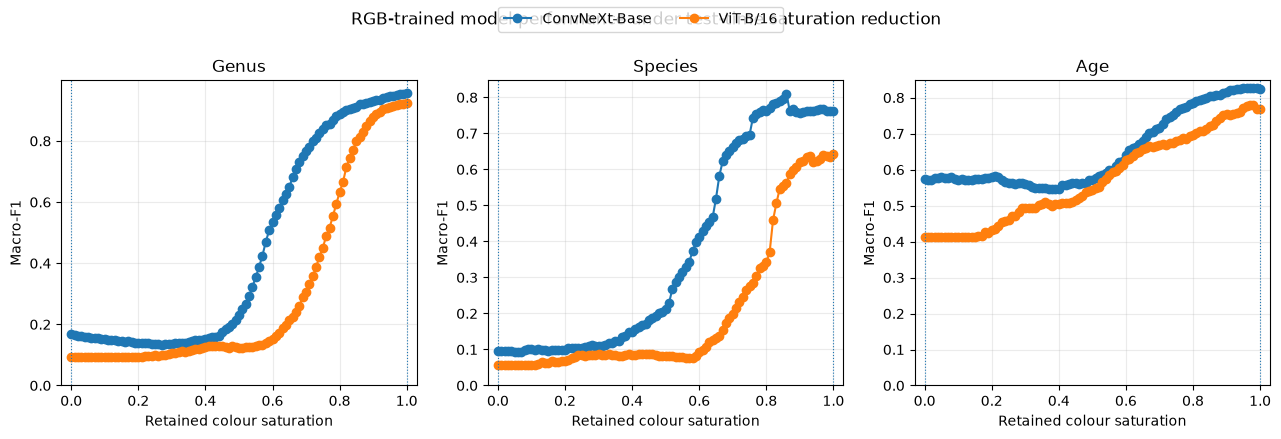

In [6]:
if cue_ratios.empty:
    print("Cue-suppression ratio data are unavailable.")
else:
    value_col = (
        "macro_f1"
        if "macro_f1" in cue_ratios.columns
        else "rgb_model_test_macro_f1"
    )

    curve = aggregate_curve(
        cue_ratios,
        value_col=value_col,
        group_cols=["model_label", "task"],
    )

    tasks = ordered_tasks(curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.2 * max(len(tasks), 1), 4.3),
        squeeze=False,
        sharey=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = curve[curve["task"] == task]
        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker="o",
                label=model,
            )
            if model_data["n"].max() > 1:
                ax.fill_between(
                    model_data["retained_saturation"],
                    model_data["mean"] - model_data["se"].fillna(0),
                    model_data["mean"] + model_data["se"].fillna(0),
                    alpha=0.2,
                )

        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Macro-F1")
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(bottom=0)
        add_reference_lines(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)))
        fig.subplots_adjust(top=0.82)

    fig.suptitle("RGB-trained model performance under test-time saturation reduction")
    save_figure(fig, "rgb_model_macro_f1_by_saturation.png")
    plt.show()


## 6. Relative performance retained from the original RGB condition

Normalising each condition to the model's original RGB macro-F1 makes model robustness easier to compare when baseline performance differs.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/rgb_model_ratio_to_original_by_saturation.png


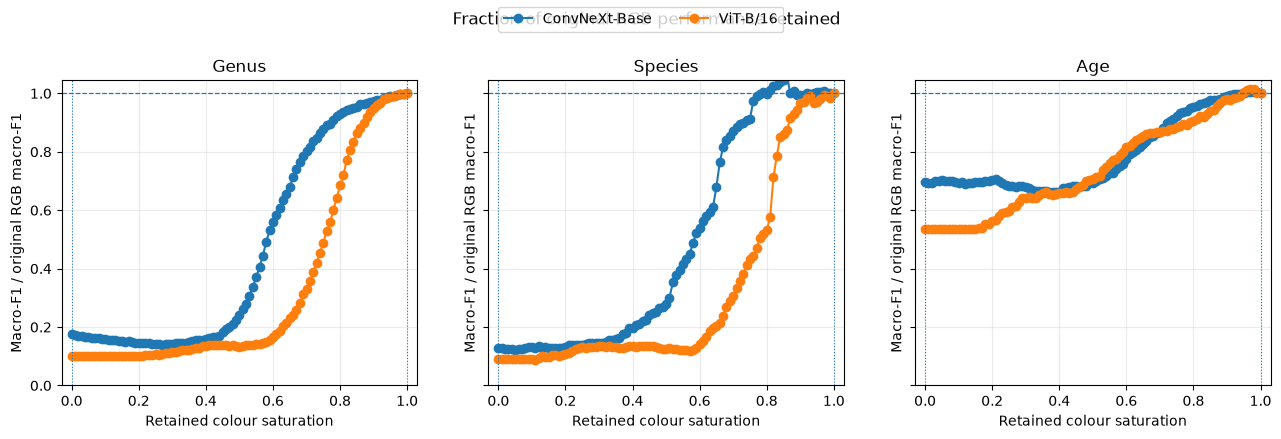

In [7]:
if cue_ratios.empty or "ratio_to_original" not in cue_ratios.columns:
    print("The ratio_to_original column is unavailable.")
else:
    ratio_curve = aggregate_curve(
        cue_ratios,
        value_col="ratio_to_original",
        group_cols=["model_label", "task"],
    )

    tasks = ordered_tasks(ratio_curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.2 * max(len(tasks), 1), 4.3),
        squeeze=False,
        sharey=True,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = ratio_curve[ratio_curve["task"] == task]
        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker="o",
                label=model,
            )

        ax.axhline(1.0, linewidth=0.9, linestyle="--")
        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Macro-F1 / original RGB macro-F1")
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(bottom=0)
        add_reference_lines(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)))
        fig.subplots_adjust(top=0.82)

    fig.suptitle("Fraction of original RGB performance retained")
    save_figure(fig, "rgb_model_ratio_to_original_by_saturation.png")
    plt.show()


## 7. Matched-condition performance

These curves show how well each architecture performs when trained and evaluated using the same saturation condition. They should not be interpreted as test-time robustness curves because the training distribution changes between points.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/matched_condition_macro_f1_by_saturation.png


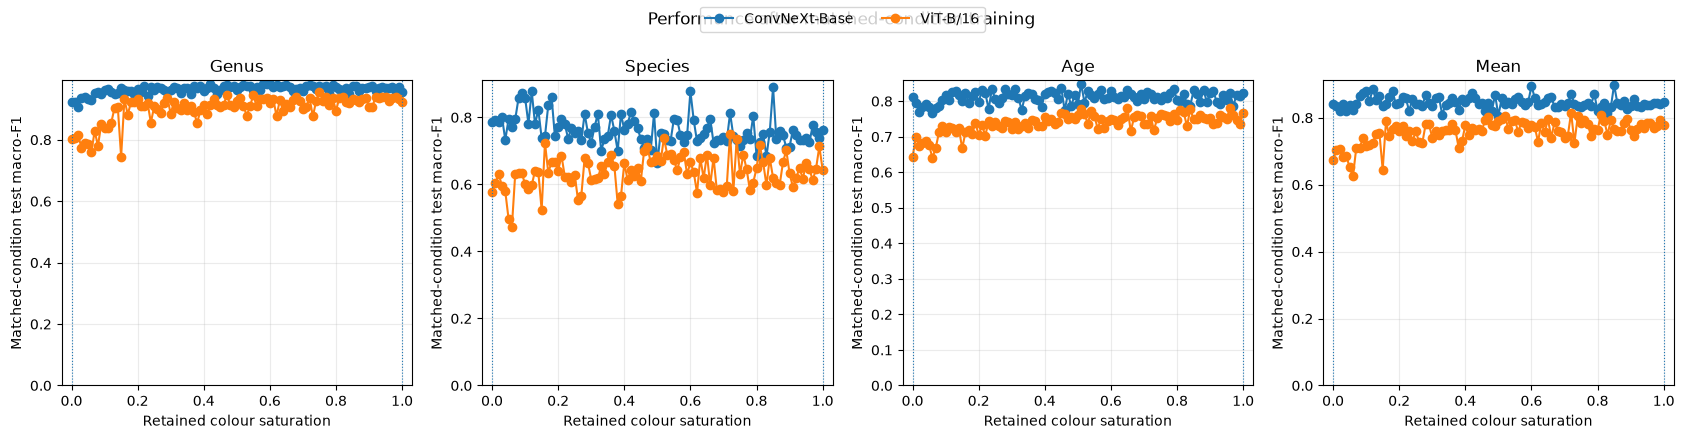

In [8]:
if matched_long.empty:
    print("Matched-condition data are unavailable.")
else:
    matched_curve = aggregate_curve(
        matched_long,
        value_col="matched_test_macro_f1",
        group_cols=["model_label", "task"],
    )

    tasks = ordered_tasks(matched_curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.2 * max(len(tasks), 1), 4.3),
        squeeze=False,
        sharey=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = matched_curve[matched_curve["task"] == task]
        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker="o",
                label=model,
            )
            if model_data["n"].max() > 1:
                ax.fill_between(
                    model_data["retained_saturation"],
                    model_data["mean"] - model_data["se"].fillna(0),
                    model_data["mean"] + model_data["se"].fillna(0),
                    alpha=0.2,
                )

        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Matched-condition test macro-F1")
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(bottom=0)
        add_reference_lines(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)))
        fig.subplots_adjust(top=0.82)

    fig.suptitle("Performance after matched-condition training")
    save_figure(fig, "matched_condition_macro_f1_by_saturation.png")
    plt.show()


## 8. Direct comparison: RGB stress test versus matched-condition training

This is the central comparison. It distinguishes performance loss caused by a distribution shift from information that is genuinely unavailable after colour removal.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/rgb_stress_test_vs_matched_training.png


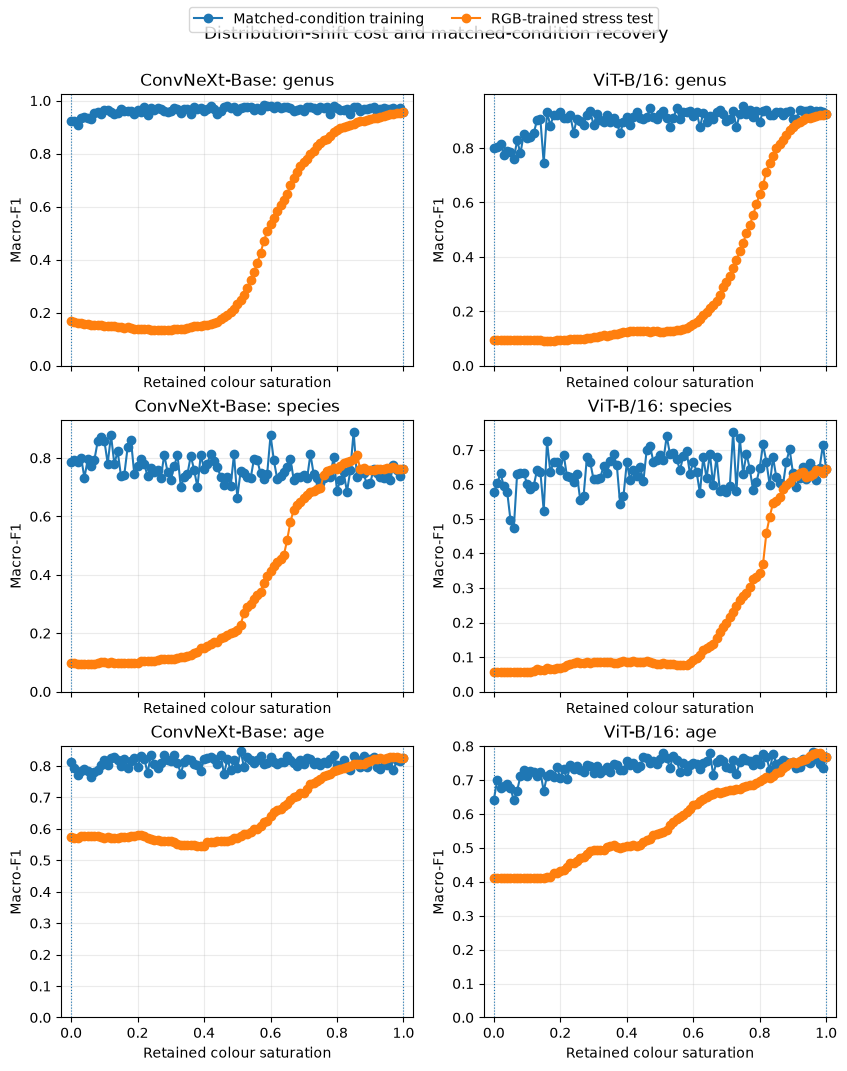

In [9]:
if comparison.empty:
    print("The matched-versus-RGB comparison file is unavailable.")
else:
    long_comparison = comparison.melt(
        id_vars=[
            c for c in [
                "model", "model_label", "task", "train_condition",
                "retained_saturation", "retained_saturation_pct",
            ]
            if c in comparison.columns
        ],
        value_vars=[
            c for c in [
                "rgb_model_test_macro_f1",
                "matched_test_macro_f1",
            ]
            if c in comparison.columns
        ],
        var_name="evaluation_regime",
        value_name="macro_f1",
    )

    regime_names = {
        "rgb_model_test_macro_f1": "RGB-trained stress test",
        "matched_test_macro_f1": "Matched-condition training",
    }
    long_comparison["evaluation_regime"] = (
        long_comparison["evaluation_regime"].map(regime_names)
    )

    curve = aggregate_curve(
        long_comparison,
        value_col="macro_f1",
        group_cols=["model_label", "task", "evaluation_regime"],
    )

    tasks = ordered_tasks(curve)
    models = sorted(curve["model_label"].dropna().unique())

    fig, axes = plt.subplots(
        len(tasks),
        len(models),
        figsize=(5.0 * max(len(models), 1), 3.8 * max(len(tasks), 1)),
        squeeze=False,
        sharex=True,
    )

    for row_index, task in enumerate(tasks):
        for col_index, model in enumerate(models):
            ax = axes[row_index][col_index]
            subset = curve[
                (curve["task"] == task)
                & (curve["model_label"] == model)
            ]

            for regime, regime_data in subset.groupby("evaluation_regime"):
                regime_data = regime_data.sort_values("retained_saturation")
                ax.plot(
                    regime_data["retained_saturation"],
                    regime_data["mean"],
                    marker="o",
                    label=regime,
                )

            ax.set_title(f"{model}: {task}")
            ax.set_xlabel("Retained colour saturation")
            ax.set_ylabel("Macro-F1")
            ax.set_xlim(-0.03, 1.03)
            ax.set_ylim(bottom=0)
            add_reference_lines(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
        fig.subplots_adjust(top=0.92)

    fig.suptitle("Distribution-shift cost and matched-condition recovery")
    save_figure(fig, "rgb_stress_test_vs_matched_training.png")
    plt.show()


## 9. Adaptation gain

The adaptation gain is:

\[
\text{matched-condition macro-F1} -
\text{RGB-trained stress-test macro-F1}.
\]

Positive values indicate that training on the altered colour distribution recovers performance.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/adaptation_gain_by_saturation.png


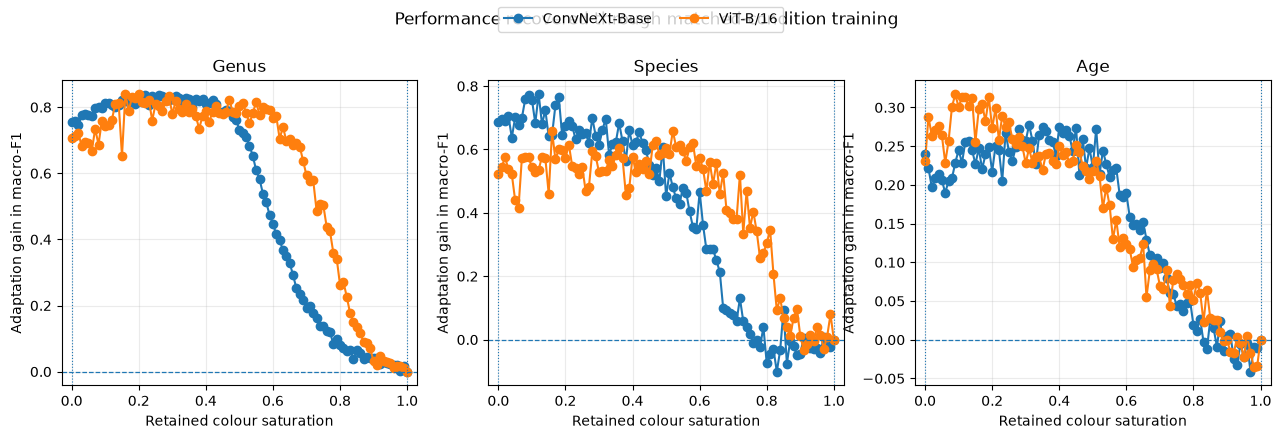

In [10]:
if comparison.empty or "adaptation_gain_macro_f1" not in comparison.columns:
    print("Adaptation-gain data are unavailable.")
else:
    gain_curve = aggregate_curve(
        comparison,
        value_col="adaptation_gain_macro_f1",
        group_cols=["model_label", "task"],
    )

    tasks = ordered_tasks(gain_curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.2 * max(len(tasks), 1), 4.3),
        squeeze=False,
        sharey=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = gain_curve[gain_curve["task"] == task]

        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker="o",
                label=model,
            )

        ax.axhline(0.0, linewidth=0.9, linestyle="--")
        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Adaptation gain in macro-F1")
        ax.set_xlim(-0.03, 1.03)
        add_reference_lines(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)))
        fig.subplots_adjust(top=0.82)

    fig.suptitle("Performance recovered through matched-condition training")
    save_figure(fig, "adaptation_gain_by_saturation.png")
    plt.show()


## 10. Species-focused figure

Because species classification is the primary biological task, this figure combines absolute performance and adaptation gain for species only.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/species_colour_robustness_summary.png


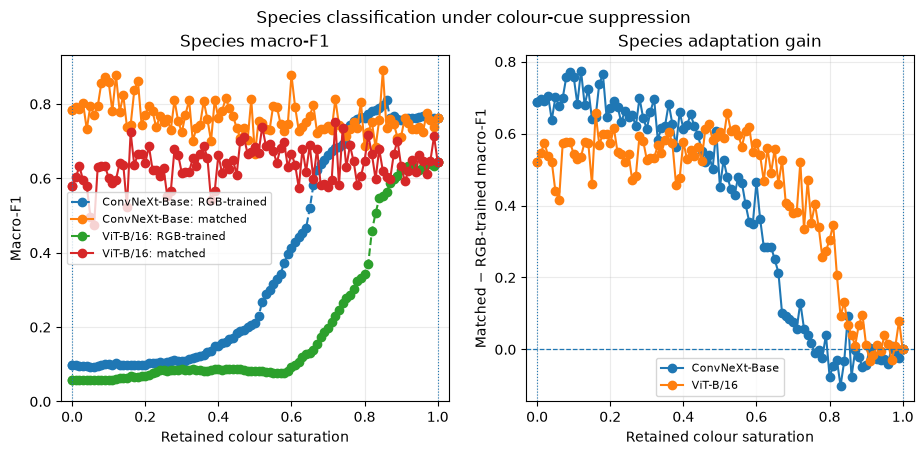

In [11]:
if comparison.empty:
    print("Comparison data are unavailable.")
else:
    species = comparison[comparison["task"] == PRIMARY_TASK].copy()

    if species.empty:
        print(f"No rows found for task={PRIMARY_TASK!r}.")
    else:
        models = sorted(species["model_label"].dropna().unique())

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(11, 4.5),
            squeeze=False,
        )
        ax_performance, ax_gain = axes[0]

        for model in models:
            model_data = species[species["model_label"] == model].copy()
            model_data = model_data.sort_values("retained_saturation")

            ax_performance.plot(
                model_data["retained_saturation"],
                model_data["rgb_model_test_macro_f1"],
                marker="o",
                linestyle="--",
                label=f"{model}: RGB-trained",
            )
            ax_performance.plot(
                model_data["retained_saturation"],
                model_data["matched_test_macro_f1"],
                marker="o",
                linestyle="-",
                label=f"{model}: matched",
            )

            ax_gain.plot(
                model_data["retained_saturation"],
                model_data["adaptation_gain_macro_f1"],
                marker="o",
                label=model,
            )

        ax_performance.set_title("Species macro-F1")
        ax_performance.set_xlabel("Retained colour saturation")
        ax_performance.set_ylabel("Macro-F1")
        ax_performance.set_xlim(-0.03, 1.03)
        ax_performance.set_ylim(bottom=0)
        add_reference_lines(ax_performance)
        ax_performance.legend(fontsize=8)

        ax_gain.axhline(0.0, linewidth=0.9, linestyle="--")
        ax_gain.set_title("Species adaptation gain")
        ax_gain.set_xlabel("Retained colour saturation")
        ax_gain.set_ylabel("Matched − RGB-trained macro-F1")
        ax_gain.set_xlim(-0.03, 1.03)
        add_reference_lines(ax_gain)
        ax_gain.legend(fontsize=8)

        fig.suptitle("Species classification under colour-cue suppression")
        save_figure(fig, "species_colour_robustness_summary.png")
        plt.show()


## 11. Model comparison

The difference below is calculated at each task and saturation level after averaging repeated runs. Positive values indicate higher macro-F1 for the first alphabetically listed model in the pair.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/matched_condition_model_difference.png


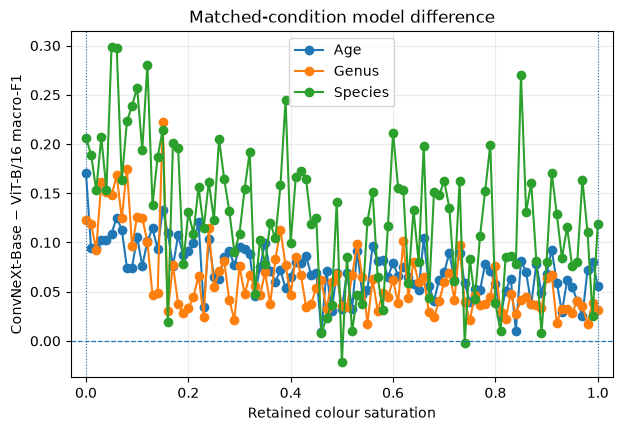

model_label,task,retained_saturation,ConvNeXt-Base,ViT-B/16,model_1,model_2,difference
0,age,0.000,0.813,0.642,ConvNeXt-Base,ViT-B/16,0.171
1,age,0.010,0.794,0.700,ConvNeXt-Base,ViT-B/16,0.094
2,age,0.020,0.770,0.675,ConvNeXt-Base,ViT-B/16,0.094
3,age,0.030,0.785,0.683,ConvNeXt-Base,ViT-B/16,0.102
4,age,0.040,0.791,0.688,ConvNeXt-Base,ViT-B/16,0.103
...,...,...,...,...,...,...,...
298,species,0.960,0.726,0.646,ConvNeXt-Base,ViT-B/16,0.080
299,species,0.970,0.776,0.612,ConvNeXt-Base,ViT-B/16,0.164
300,species,0.980,0.758,0.647,ConvNeXt-Base,ViT-B/16,0.110
301,species,0.990,0.739,0.713,ConvNeXt-Base,ViT-B/16,0.025


In [12]:
def pairwise_model_difference(
    frame: pd.DataFrame,
    value_col: str,
) -> pd.DataFrame:
    summary = (
        frame
        .dropna(subset=["model_label", "task", "retained_saturation", value_col])
        .groupby(["model_label", "task", "retained_saturation"])[value_col]
        .mean()
        .reset_index()
    )

    wide = summary.pivot_table(
        index=["task", "retained_saturation"],
        columns="model_label",
        values=value_col,
    )

    models = list(wide.columns)
    if len(models) != 2:
        print(f"Expected two models, found {models}.")
        return pd.DataFrame()

    result = wide.reset_index()
    result["model_1"] = models[0]
    result["model_2"] = models[1]
    result["difference"] = result[models[0]] - result[models[1]]
    return result


if comparison.empty:
    print("Comparison data are unavailable.")
else:
    model_difference = pairwise_model_difference(
        comparison,
        value_col="matched_test_macro_f1",
    )

    if not model_difference.empty:
        fig, ax = plt.subplots(figsize=(7, 4.5))

        for task, task_data in model_difference.groupby("task"):
            task_data = task_data.sort_values("retained_saturation")
            ax.plot(
                task_data["retained_saturation"],
                task_data["difference"],
                marker="o",
                label=task.capitalize(),
            )

        ax.axhline(0.0, linewidth=0.9, linestyle="--")
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel(
            f"{model_difference['model_1'].iloc[0]} − "
            f"{model_difference['model_2'].iloc[0]} macro-F1"
        )
        ax.set_title("Matched-condition model difference")
        ax.set_xlim(-0.03, 1.03)
        add_reference_lines(ax)
        ax.legend()

        save_figure(fig, "matched_condition_model_difference.png")
        plt.show()

        display(model_difference)


## 12. Heatmaps of performance across tasks and saturation levels

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_rgb_stress_ConvNeXt_Base.png


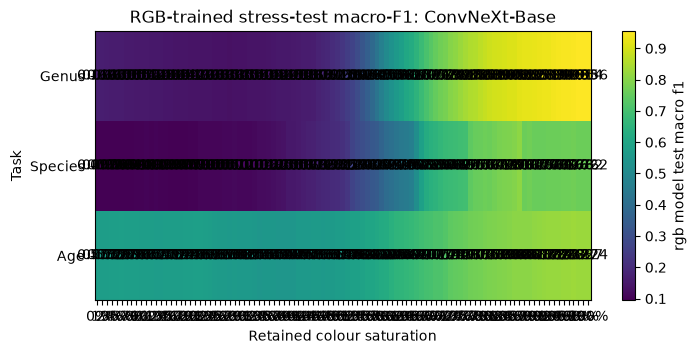

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_rgb_stress_ViT_B_16.png


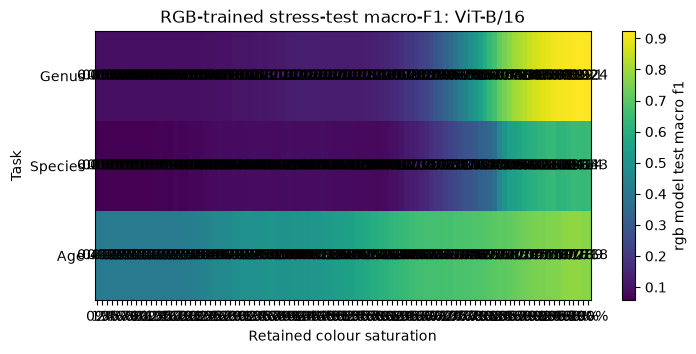

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_matched_ConvNeXt_Base.png


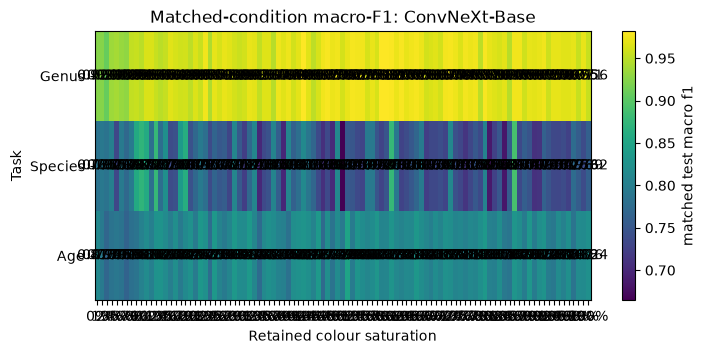

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_matched_ViT_B_16.png


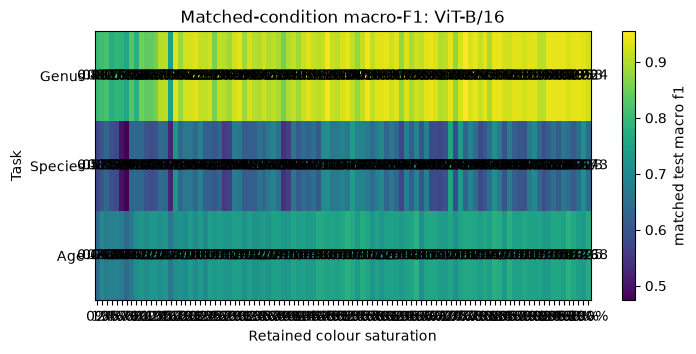

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_adaptation_gain_ConvNeXt_Base.png


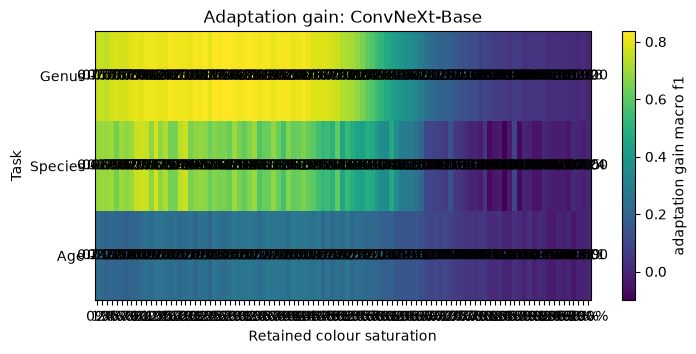

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_colour_robustness/heatmap_adaptation_gain_ViT_B_16.png


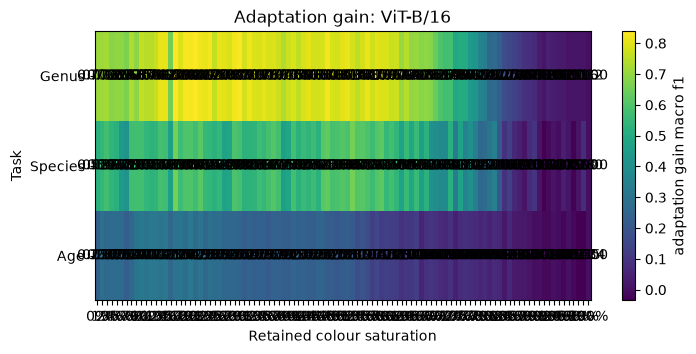

In [13]:
def plot_heatmap(
    frame: pd.DataFrame,
    value_col: str,
    title_prefix: str,
    filename_prefix: str,
) -> None:
    if frame.empty or value_col not in frame.columns:
        print(f"Cannot plot {value_col}.")
        return

    for model, model_data in frame.groupby("model_label"):
        table = (
            model_data
            .groupby(["task", "retained_saturation"])[value_col]
            .mean()
            .unstack("retained_saturation")
        )

        task_index = [task for task in TASK_ORDER if task in table.index]
        task_index += [task for task in table.index if task not in task_index]
        table = table.reindex(task_index)
        table = table.reindex(sorted(table.columns), axis=1)

        fig, ax = plt.subplots(figsize=(8, 3.5))
        image = ax.imshow(table.to_numpy(), aspect="auto")

        ax.set_xticks(range(len(table.columns)))
        ax.set_xticklabels([f"{100*x:.0f}%" for x in table.columns])
        ax.set_yticks(range(len(table.index)))
        ax.set_yticklabels([str(x).capitalize() for x in table.index])

        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Task")
        ax.set_title(f"{title_prefix}: {model}")

        for i in range(table.shape[0]):
            for j in range(table.shape[1]):
                value = table.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.3f}", ha="center", va="center")

        fig.colorbar(image, ax=ax, label=value_col.replace("_", " "))
        save_figure(
            fig,
            f"{filename_prefix}_{re.sub(r'[^A-Za-z0-9]+', '_', model).strip('_')}.png",
        )
        plt.show()


plot_heatmap(
    comparison,
    value_col="rgb_model_test_macro_f1",
    title_prefix="RGB-trained stress-test macro-F1",
    filename_prefix="heatmap_rgb_stress",
)

plot_heatmap(
    comparison,
    value_col="matched_test_macro_f1",
    title_prefix="Matched-condition macro-F1",
    filename_prefix="heatmap_matched",
)

plot_heatmap(
    comparison,
    value_col="adaptation_gain_macro_f1",
    title_prefix="Adaptation gain",
    filename_prefix="heatmap_adaptation_gain",
)


## 13. Summary tables

The tables below support concise reporting of:

- original RGB performance;
- greyscale stress-test performance;
- matched greyscale performance;
- relative performance retained without colour;
- performance recovered by matched-condition training.


In [14]:
def nearest_condition(
    frame: pd.DataFrame,
    target: float,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    out = frame.copy()
    out["distance_to_target"] = (
        out["retained_saturation"] - target
    ).abs()

    minimum = (
        out.groupby(["model_label", "task"])["distance_to_target"]
        .transform("min")
    )
    return out[out["distance_to_target"] == minimum].copy()


if comparison.empty:
    print("Comparison data are unavailable.")
else:
    original = nearest_condition(comparison, 1.0)
    greyscale = nearest_condition(comparison, 0.0)

    original_summary = (
        original
        .groupby(["model_label", "task"])
        .agg(
            original_rgb_macro_f1=("rgb_model_test_macro_f1", "mean"),
            original_matched_macro_f1=("matched_test_macro_f1", "mean"),
        )
        .reset_index()
    )

    greyscale_summary = (
        greyscale
        .groupby(["model_label", "task"])
        .agg(
            greyscale_rgb_stress_macro_f1=("rgb_model_test_macro_f1", "mean"),
            greyscale_matched_macro_f1=("matched_test_macro_f1", "mean"),
            greyscale_adaptation_gain=("adaptation_gain_macro_f1", "mean"),
            greyscale_ratio_to_rgb_original=("rgb_ratio_to_original", "mean"),
            greyscale_matched_ratio_to_rgb_original=(
                "matched_ratio_to_rgb_original",
                "mean",
            ),
        )
        .reset_index()
    )

    summary_table = original_summary.merge(
        greyscale_summary,
        on=["model_label", "task"],
        how="outer",
    )

    summary_table["stress_test_drop"] = (
        summary_table["original_rgb_macro_f1"]
        - summary_table["greyscale_rgb_stress_macro_f1"]
    )
    summary_table["remaining_gap_after_matched_training"] = (
        summary_table["original_rgb_macro_f1"]
        - summary_table["greyscale_matched_macro_f1"]
    )

    task_rank = {task: i for i, task in enumerate(TASK_ORDER)}
    summary_table["_task_rank"] = summary_table["task"].map(task_rank).fillna(999)
    summary_table = (
        summary_table
        .sort_values(["model_label", "_task_rank", "task"])
        .drop(columns="_task_rank")
        .reset_index(drop=True)
    )

    display(summary_table)

    if SAVE_TABLES:
        summary_path = TABLE_DIR / "colour_robustness_summary.csv"
        summary_table.to_csv(summary_path, index=False)
        print("Saved:", summary_path)


,model_label,task,original_rgb_macro_f1,original_matched_macro_f1,greyscale_rgb_stress_macro_f1,greyscale_matched_macro_f1,greyscale_adaptation_gain,greyscale_ratio_to_rgb_original,greyscale_matched_ratio_to_rgb_original,stress_test_drop,remaining_gap_after_matched_training
0,ConvNeXt-Base,genus,0.956,0.956,0.169,0.924,0.755,0.177,0.967,0.786,0.031
1,ConvNeXt-Base,species,0.762,0.762,0.097,0.785,0.688,0.127,1.030,0.665,-0.023
2,ConvNeXt-Base,age,0.824,0.824,0.573,0.813,0.240,0.695,0.986,0.251,0.012
3,ViT-B/16,genus,0.924,0.924,0.093,0.801,0.708,0.101,0.867,0.831,0.123
4,ViT-B/16,species,0.643,0.643,0.057,0.578,0.521,0.089,0.899,0.586,0.065
5,ViT-B/16,age,0.768,0.768,0.412,0.642,0.230,0.536,0.836,0.356,0.126


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_colour_robustness/colour_robustness_summary.csv


## 14. Area-under-curve robustness score

The normalised area under the saturation-response curve summarises performance across the full saturation range. It should be interpreted alongside the original-condition macro-F1 because two models can have similar relative robustness but different absolute performance.


In [15]:
def trapezoidal_auc(
    group: pd.DataFrame,
    value_col: str,
) -> float:
    clean = (
        group[["retained_saturation", value_col]]
        .dropna()
        .groupby("retained_saturation", as_index=False)[value_col]
        .mean()
        .sort_values("retained_saturation")
    )

    if len(clean) < 2:
        return float("nan")

    x = clean["retained_saturation"].to_numpy()
    y = clean[value_col].to_numpy()
    width = x.max() - x.min()

    if width == 0:
        return float("nan")

    return float(np.trapz(y, x) / width)


if comparison.empty:
    print("Comparison data are unavailable.")
else:
    auc_rows = []

    for (model, task), group in comparison.groupby(["model_label", "task"]):
        auc_rows.append({
            "model": model,
            "task": task,
            "rgb_stress_auc": trapezoidal_auc(
                group,
                "rgb_model_test_macro_f1",
            ),
            "matched_condition_auc": trapezoidal_auc(
                group,
                "matched_test_macro_f1",
            ),
            "adaptation_gain_auc": trapezoidal_auc(
                group,
                "adaptation_gain_macro_f1",
            ),
        })

    auc_table = pd.DataFrame(auc_rows)
    display(auc_table)

    if SAVE_TABLES:
        path = TABLE_DIR / "saturation_curve_auc.csv"
        auc_table.to_csv(path, index=False)
        print("Saved:", path)


AttributeError: module 'numpy' has no attribute 'trapz'

## 15. Optional uncertainty analysis across repeated runs

If multiple random seeds or repeated runs are available for each model and condition, use these data for confidence intervals or paired comparisons. With only one run per condition, the figures should be interpreted descriptively rather than inferentially.


In [ ]:
def bootstrap_mean_ci(
    values: pd.Series,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> tuple[float, float, float]:
    clean = values.dropna().to_numpy(dtype=float)

    if len(clean) == 0:
        return float("nan"), float("nan"), float("nan")

    if len(clean) == 1:
        value = float(clean[0])
        return value, float("nan"), float("nan")

    rng = np.random.default_rng(seed)
    samples = rng.choice(
        clean,
        size=(n_bootstrap, len(clean)),
        replace=True,
    )
    bootstrap_means = samples.mean(axis=1)

    alpha = 1.0 - confidence
    lower, upper = np.quantile(
        bootstrap_means,
        [alpha / 2.0, 1.0 - alpha / 2.0],
    )

    return float(clean.mean()), float(lower), float(upper)


if not comparison.empty:
    uncertainty_rows = []

    for keys, group in comparison.groupby(
        ["model_label", "task", "retained_saturation"]
    ):
        mean, lower, upper = bootstrap_mean_ci(
            group["adaptation_gain_macro_f1"]
        )
        uncertainty_rows.append({
            "model": keys[0],
            "task": keys[1],
            "retained_saturation": keys[2],
            "mean_adaptation_gain": mean,
            "ci_lower": lower,
            "ci_upper": upper,
            "n": group["adaptation_gain_macro_f1"].notna().sum(),
        })

    uncertainty_table = pd.DataFrame(uncertainty_rows)
    display(uncertainty_table.head(20))


## 16. Suggested interpretation framework

Use the following distinctions when writing the results:

- A decrease in the **RGB-trained stress-test curve** indicates dependence on colour and/or sensitivity to colour-distribution shift.
- A positive **adaptation gain** indicates that some lost performance is recoverable by training on the altered distribution.
- A persistent gap between **matched greyscale performance** and **original RGB performance** suggests that colour contains discriminative information that cannot be recovered from shape and texture alone.
- Similar stress-test curves for ConvNeXt and ViT do not establish that the architectures use identical visual cues. They only indicate similar output-level sensitivity under the tested transformations.
- Age/life-stage classification may respond differently from taxonomic classification because colour can encode developmental condition rather than species identity.


## 17. Compact manuscript-ready results table

The following table contains the principal values likely to be reported in a paper or thesis chapter.


In [ ]:
if comparison.empty:
    print("Comparison data are unavailable.")
else:
    report_table = (
        comparison
        .groupby(
            ["model_label", "task", "retained_saturation"],
            dropna=False,
        )
        .agg(
            rgb_stress_macro_f1=("rgb_model_test_macro_f1", "mean"),
            matched_macro_f1=("matched_test_macro_f1", "mean"),
            adaptation_gain=("adaptation_gain_macro_f1", "mean"),
            rgb_ratio_to_original=("rgb_ratio_to_original", "mean"),
            matched_ratio_to_original=(
                "matched_ratio_to_rgb_original",
                "mean",
            ),
            n=("matched_test_macro_f1", "count"),
        )
        .reset_index()
        .sort_values(["task", "model_label", "retained_saturation"])
    )

    display(report_table)

    if SAVE_TABLES:
        path = TABLE_DIR / "manuscript_results_table.csv"
        report_table.to_csv(path, index=False)
        print("Saved:", path)
